Identifica la variable objetivo (target)

  R/ La varible objetivo es Loan_Status

Responde:
  
  ○ ¿Es un problema de clasificación o regresión?  

    R/ Clasificacion

  ○ ¿Por qué?

    R/ Porque lo que intentamos determinar es una categoria

Describe brevemente el contexto del problema

  R/ El problema radica en encontrar si se puede aprobar o no un credito a una persona segun sus condiciones


In [63]:
############ Importar librerias para ML ##############

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [65]:
############ Leer archivo desde el explorador ##################

In [66]:
from google.colab import files
uploaded =files.upload()

Saving train_u6lujuX_CVtuZ9i.csv to train_u6lujuX_CVtuZ9i (1).csv


### - Parte 2 – Exploración de datos (EDA básica)

In [67]:
df = pd.read_csv('train_u6lujuX_CVtuZ9i.csv')
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [68]:
df.shape

(614, 13)

In [69]:
df.describe(include='all')

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
count,614,601,611,599,614,582,614.000000,614.000000,592.000000,600.00000,564.000000,614,614
unique,614,2,2,4,2,2,NaN,NaN,NaN,NaN,NaN,3,2
top,LP002990,Male,Yes,0,Graduate,No,NaN,NaN,NaN,NaN,NaN,Semiurban,Y
freq,1,489,398,345,480,500,NaN,NaN,NaN,NaN,NaN,233,422
mean,NaN,NaN,NaN,NaN,NaN,NaN,5403.459283,1621.245798,146.412162,342.00000,0.842199,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,6109.041673,2926.248369,85.587325,65.12041,0.364878,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,150.000000,0.000000,9.000000,12.00000,0.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,2877.500000,0.000000,100.000000,360.00000,1.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,3812.500000,1188.500000,128.000000,360.00000,1.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,5795.000000,2297.250000,168.000000,360.00000,1.000000,NaN,NaN


In [70]:
############# Dado que la columna unique nos muestra coherencia entre las columnas y la cantidad de "categorias", no vamos a usar unique ###########
############# Ademas en este caso aunque aparezcan datos muy elevados no usaremos outlayers ya que vamoz a estandarizar todos los registros numericos #########

In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [72]:
# Verificar si hay datos duplicados de la columna de Loan_ID
datos_repetidos = df['Loan_ID'].duplicated().sum()

print(datos_repetidos)

0


In [73]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [74]:
conteo = df.groupby(['Gender', 'Loan_Status']).size().reset_index(name='cantidad')
print(conteo)

   Gender Loan_Status  cantidad
0  Female           N        37
1  Female           Y        75
2    Male           N       150
3    Male           Y       339


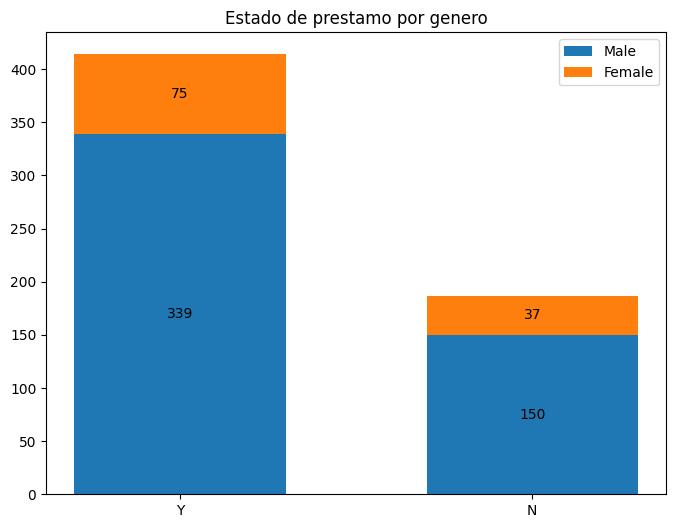

In [75]:
Loan_Status = ('Y', 'N')
sex_counts = {
    'Male': np.array([339, 150]),
    'Female': np.array([75, 37])
}

fig, ax = plt.subplots(figsize=(8, 6))
bottom = np.zeros(len(Loan_Status))
width = 0.6

for sex, sex_count in sex_counts.items():
    p = ax.bar(Loan_Status, sex_count, width, label=sex, bottom=bottom)
    bottom += sex_count


    ax.bar_label(p, label_type='center')

ax.set_title('Estado de prestamo por genero')
ax.legend()

plt.show()

In [76]:
conteo = df.groupby('Property_Area').size().reset_index(name='cantidad')
print(conteo)

  Property_Area  cantidad
0         Rural       179
1     Semiurban       233
2         Urban       202


([<matplotlib.patches.Wedge at 0x7d3fa94ce540>,
 [Text(0.5629463511003223, 0.9450351346816862, 'Urban'),
  Text(-1.0923918294543944, -0.1291514264004911, 'Semiurban'),
  Text(0.6700096359110586, -0.8724030535173125, 'Rural')])

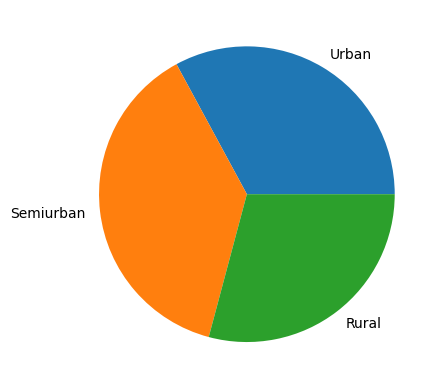

In [77]:
labels = 'Urban', 'Semiurban', 'Rural'
sizes = [202, 233, 179]

fig, ax = plt.subplots()
ax.pie(sizes, labels=labels)

### - Parte 3 – Preparación de datos

In [78]:
# Corregir tipos de datos incorrectos
df["Dependents"] = pd.to_numeric(df["Dependents"], errors="coerce")

In [79]:
# Manejo de los valores nulos
df = df.dropna(subset=['Married'])
df["Dependents"] = df["Dependents"].fillna(df["Dependents"].median())
df["Self_Employed"] = df["Self_Employed"].fillna(df["Self_Employed"].mode()[0])
df["LoanAmount"] = df["LoanAmount"].fillna(df["LoanAmount"].median())
df["Loan_Amount_Term"] = df["Loan_Amount_Term"].fillna(df["Loan_Amount_Term"].mode()[0])
df["Credit_History"] = df["Credit_History"].fillna(df["Credit_History"].mode()[0])



In [80]:
# Eliminar columnas inesarias para el modelo de ML
df = df.drop(columns=["Loan_ID", "Gender"])

In [81]:
################## Verificar ###################

In [82]:
df.head()

,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,No,0.0,Graduate,No,5849,0.0,127.5,360.0,1.0,Urban,Y
1,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Yes,0.0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,No,0.0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [83]:
df.isnull().sum()

,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0
Credit_History,0
Property_Area,0


In [84]:
df.shape

(611, 11)

In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 611 entries, 0 to 613
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Married            611 non-null    object 
 1   Dependents         611 non-null    float64
 2   Education          611 non-null    object 
 3   Self_Employed      611 non-null    object 
 4   ApplicantIncome    611 non-null    int64  
 5   CoapplicantIncome  611 non-null    float64
 6   LoanAmount         611 non-null    float64
 7   Loan_Amount_Term   611 non-null    float64
 8   Credit_History     611 non-null    float64
 9   Property_Area      611 non-null    object 
 10  Loan_Status        611 non-null    object 
dtypes: float64(5), int64(1), object(5)
memory usage: 57.3+ KB


In [86]:
#Convertir categorias
df = pd.get_dummies(df,drop_first=True)
# Ver nombre columna obj cambiado
print(df.columns.tolist())

['Dependents', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Married_Yes', 'Education_Not Graduate', 'Self_Employed_Yes', 'Property_Area_Semiurban', 'Property_Area_Urban', 'Loan_Status_Y']


In [87]:
X = df.drop('Loan_Status_Y', axis=1)
y = df['Loan_Status_Y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.info()
X_test.info()

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

<class 'pandas.core.frame.DataFrame'>
Index: 488 entries, 564 to 102
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Dependents               488 non-null    float64
 1   ApplicantIncome          488 non-null    int64  
 2   CoapplicantIncome        488 non-null    float64
 3   LoanAmount               488 non-null    float64
 4   Loan_Amount_Term         488 non-null    float64
 5   Credit_History           488 non-null    float64
 6   Married_Yes              488 non-null    bool   
 7   Education_Not Graduate   488 non-null    bool   
 8   Self_Employed_Yes        488 non-null    bool   
 9   Property_Area_Semiurban  488 non-null    bool   
 10  Property_Area_Urban      488 non-null    bool   
dtypes: bool(5), float64(5), int64(1)
memory usage: 29.1 KB
<class 'pandas.core.frame.DataFrame'>
Index: 123 entries, 81 to 23
Data columns (total 11 columns):
 #   Column                   Non-Nu

In [88]:
################## Parte 4 – Modelado #################

In [89]:
# regresion logistica

log_reg = LogisticRegression(max_iter=1000) #se usan 1000 iteraciones para asegurar la convergencia
log_reg.fit(X_train, y_train) #aprendemos el modelo con los datos de entrenamiento
y_pred_log = log_reg.predict(X_test) # tomar el modelo aprendido y predecir con los datos de prueba

In [90]:
#arbol de decision
arbol_decision = DecisionTreeClassifier(max_depth=5) #5 arboles
arbol_decision.fit(X_train, y_train)
y_pred_arbol = arbol_decision.predict(X_test)


In [91]:
################# Parte 5 – Evaluación del modelo ###############

In [92]:
matriz_confusion = confusion_matrix(y_test, y_pred_log)
print("Matriz de confusión:")
print(matriz_confusion)

Matriz de confusión:
[[16 19]
 [ 2 86]]


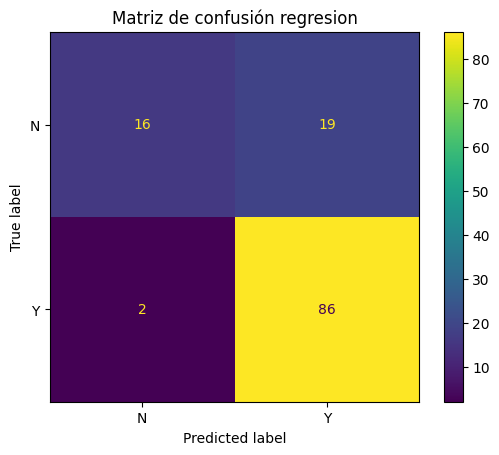

0.8292682926829268
[[16 19]
 [ 2 86]]
              precision    recall  f1-score   support

       False       0.89      0.46      0.60        35
        True       0.82      0.98      0.89        88

    accuracy                           0.83       123
   macro avg       0.85      0.72      0.75       123
weighted avg       0.84      0.83      0.81       123



In [93]:
mapa_calor_confusion = ConfusionMatrixDisplay(confusion_matrix=matriz_confusion, display_labels=["N", "Y"])
mapa_calor_confusion.plot()
plt.title("Matriz de confusión regresion")
plt.show()

print(accuracy_score(y_test, y_pred_log))
print(confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))


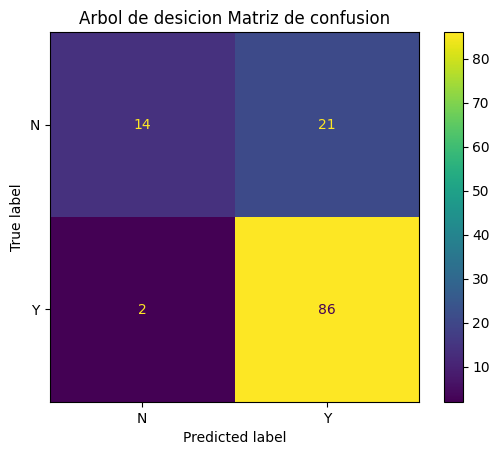

0.8130081300813008
[[14 21]
 [ 2 86]]
              precision    recall  f1-score   support

       False       0.88      0.40      0.55        35
        True       0.80      0.98      0.88        88

    accuracy                           0.81       123
   macro avg       0.84      0.69      0.72       123
weighted avg       0.82      0.81      0.79       123



In [94]:
arbol_matriz_confusion = confusion_matrix(y_test, y_pred_arbol)
mapa_calor_confusion = ConfusionMatrixDisplay(confusion_matrix=arbol_matriz_confusion, display_labels=["N", "Y"])
mapa_calor_confusion.plot()
plt.title("Arbol de desicion Matriz de confusion")
plt.show()

print(accuracy_score(y_test, y_pred_arbol))
print(confusion_matrix(y_test, y_pred_arbol))
print(classification_report(y_test, y_pred_arbol))


In [95]:
# Ajuste hiperparametros
parametros = {
    'log_reg': (LogisticRegression(max_iter=200, solver = 'lbfgs'), {'C': [0.01, 0.1, 1, 10]}),
    'arbol_decision': (DecisionTreeClassifier(random_state=42), {'max_depth' : [2, 4, 6, 8, 10]})
}

In [96]:
mejores_modelos = {}

for name, (modelo, params) in parametros.items():

    print(f"\nBuscando mejores hiperparámetros para {name}...")

    grid = GridSearchCV(
        modelo,
        params,
        cv=4,
        scoring='f1_macro'
    )

    grid.fit(X_train, y_train)

    print("Mejores parámetros:", grid.best_params_)

    mejor_modelo = grid.best_estimator_

    y_pred = mejor_modelo.predict(X_test)

    f1_macro = f1_score(
        y_test,
        y_pred,
        average='macro'
    )

    print(f"F1-macro en test: {f1_macro:.4f}")

    mejores_modelos[name] = {

        'model': mejor_modelo,

        'f1_macro': f1_macro,

        'params': grid.best_params_
    }


Buscando mejores hiperparámetros para log_reg...
Mejores parámetros: {'C': 0.1}
F1-macro en test: 0.7475

Buscando mejores hiperparámetros para arbol_decision...
Mejores parámetros: {'max_depth': 6}
F1-macro en test: 0.6763


In [97]:
############ Parte 6 – Interpretación ##############

In [98]:
# Obtener el mejor modelo de regresión logística del diccionario mejores_modelos
mejor_log_reg_modelo = mejores_modelos['log_reg']['model']

# Obtener los coeficientes del modelo
coeficientes_log_reg = mejor_log_reg_modelo.coef_[0]

# Crear un DataFrame para visualizar los coeficientes junto con los nombres de las variables
df_coeficientes_log_reg = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': coeficientes_log_reg
}).sort_values(by='Coeficiente', ascending=False)

print("Coeficientes del modelo de Regresión Logística:")
print(df_coeficientes_log_reg)

Coeficientes del modelo de Regresión Logística:
                   Variable  Coeficiente
5            Credit_History     1.141725
9   Property_Area_Semiurban     0.367534
6               Married_Yes     0.251616
0                Dependents     0.094641
10      Property_Area_Urban    -0.000111
1           ApplicantIncome    -0.034473
4          Loan_Amount_Term    -0.036474
8         Self_Employed_Yes    -0.037987
3                LoanAmount    -0.056152
7    Education_Not Graduate    -0.147435
2         CoapplicantIncome    -0.148333


¿Qué tan bueno es el modelo?

  R/  Dado el resultado de la evaluacion el mejor modelo es el de regresion logistica con 'C' = 0.1, arroja un F1-Macro en test  de 0.7475 asi que es un buen modelo, pero igualmente hace falta para dar un resultado mas satisfactorio, ya que el F1-Macro determina la capacidad de reconocer los valores minoritarios que en este caso son los de los creditos no aprobados, que para una estartegia de negocio se debe ser sumamente cuidadoso por el nivel de riego que representan.

¿Qué variable parece influir más en la predicción?

  R/ La variable que mas influye segun  los coeficientes del modelo es Credit_History
   
¿Qué mejorarías si tuvieras más tiempo?

  R/ Buscar otro modelo quiza, alguno que diera un valor de F1 mas alto para el valor negativc ya que es donde puede estar peligrando mas el dinero de la compañia en este caso